In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


Final s value (increased by 5% to reduce overfitting): 112.35357142857143


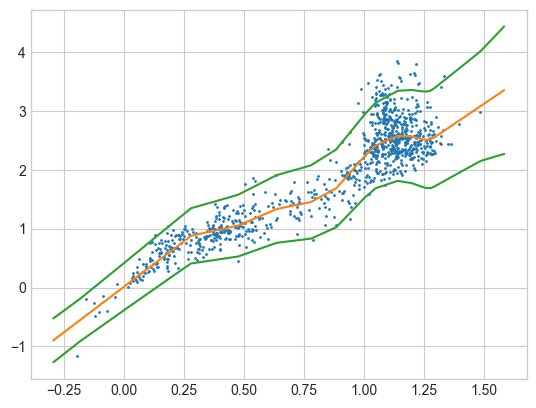

In [ ]:
# from ExoRM.get_data import get_data
# get_data()

# from ExoRM.initialize_model import initialize_model
# initialize_model()

# Use these to initialize / update the model

In [ ]:
from ExoRM import read_rm_data, load_model, ForecasterRM, preprocess_data, read_exoplanet_data

import numpy
import matplotlib.pyplot as plot
import matplotlib
import pandas
import seaborn
import math
import time

save = False # save the figures / csv to files
plot.style.use('seaborn-v0_8-paper')
seaborn.set_theme(style = 'white', context = 'paper')
matplotlib.rcParams['figure.figsize'] = [4, 3]
matplotlib.rcParams['axes.labelsize'] = 10  # Axis label font size
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['figure.constrained_layout.use'] = True

matplotlib.rcParams['lines.markersize'] = 1.2  # Default marker size (scatter size)
matplotlib.rcParams['lines.linewidth'] = 2   # Default line width

path = 'Paper Material/ExoRM'

data = read_rm_data()
data = preprocess_data(data)
data['length'] = data['name'].str.len()
data.sort_values('length', inplace = True)
data = data[['name', 'radius', 'mass', 'density']].reset_index(drop = True)
data

In [ ]:
p = data.iloc[0]
p

In [ ]:
model = load_model()
ForecasterRM.log_mode = False

e_m = model.predict_linear(p['radius'])
f_m = ForecasterRM.forecaster(p['radius'])

e_m, f_m, p['mass']